**Project Title:** Digital media consumption and market trends\
**Author:** Maverick Luke \
**Date:** 11th March, 2025 

# Imports and Constants

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import json
from datetime import datetime, timedelta
from time import sleep
import yfinance as yf
import praw
import re
import statsmodels.api as sm
from scipy import stats


In [29]:
# Constants for retrieving data from APIs (not necessary to run the code)
# These constants are used to store the API keys and other sensitive information
with open('tmdb_api_key.txt', 'r') as file:
    for line in file:
        clean_line = line.strip()
        if clean_line:
            API_KEY = clean_line # your api key (can be obtained from https://github.com/rickylawson/freekeys/blob/master/index.js)
            break

with open('reddit_client.txt', 'r') as file:
    lines = file.readlines()
    CLIENT_ID = lines[0].strip() # your client id 
    CLIENT_SECRET = lines[1].strip() # your client secret
    USER_AGENT = lines[2].strip() # python:JSC370.project:v1.0 (by /u/YOUR_REDDIT_USERNAME)

# Introduction

The streaming media landscape has evolved dramatically in recent years, with platforms like Netflix and Disney+ competing intensely for subscribers. Original content has become a primary differentiator in this competition, with platforms investing billions in developing exclusive shows and movies. Meanwhile, social media platforms like Reddit serve as immediate indicators of audience reception, potentially signaling a release's success or failure. This intersection of streaming content strategies and social media engagement raises an important question for investors: How do major content releases on these platforms affect their stock market performance, and can social media metrics serve as leading indicators for these market movements?

## Research Question
This project addresses the question: **How do major streaming content releases on Netflix and Disney+ affect their respective stock prices in the short term, and does social media engagement correlate with these market movements?** \
Specifically, we analyze:

1. Whether stock prices show abnormal returns in the 3-day window following content releases
2. If there are differences in market impact between TV shows and movies
3. Whether Reddit engagement metrics correlate with stock price movements
4. If certain content types or genres generate stronger market reactions than others

# Methods

The study combines data from three distinct sources to examine relationships between streaming content releases, stock market performance, and social media engagement:

- Streaming Content Data: **The Movie Database (TMDB) API** was used to collect information about Netflix and Disney+ releases, including release dates, popularity scores, and genres. Both TV shows and movies were included to ensure a sufficient sample size.
- Stock Market Data: Financial data for Netflix (NFLX), Disney (DIS), and the S&P 500 index was collected using the Yahoo Finance API via the Python **yfinance** package. Daily closing prices, trading volume, and other metrics were gathered for the period from September 2024 to March 2025.
- Social Media Engagement Data: Reddit's API was accessed using the Python **praw** library to collect post and comment data related to each content release. Data was collected from relevant subreddits including r/television, r/netflix, r/DisneyPlus, r/streaming.

## API Implementation
The following code demonstrates how data was collected from each API source: (Note that the API calls take some time and requires API keys (for TMDB) and client id and client secret (for Reddit praw). To improve efficiency, I’ve saved the datasets as CSV files for quicker retrieval. The retrieval code is located right below the API calls functions)

In [ ]:
# Function to get the top releases for a given streaming provider
# The function fetches the top TV shows released on the specified streaming platform
def get_top_releases(provider_id, start_date, end_date, api_key = API_KEY):
    base_url_tv = "https://api.themoviedb.org/3/discover/tv"
    base_url_movie = "https://api.themoviedb.org/3/discover/movie"
    
    tv_results = []
    movie_results = []

    page_tv = 1
    page_movie = 1
    
    while True:
        params_tv = {
            'api_key': api_key,
            'with_watch_providers': provider_id,
            'watch_region': 'US',
            'first_air_date.gte': start_date,
            'first_air_date.lte': end_date,
            'sort_by': 'popularity.desc',
            'page': page_tv
        }
        params_movie = {
            'api_key': api_key,
            'with_watch_providers': provider_id,
            'watch_region': 'US',
            'primary_release_date.gte': start_date,
            'primary_release_date.lte': end_date,
            'sort_by': 'popularity.desc',
            'page': page_movie
        }

        if page_tv < 6: 
            response_tv = requests.get(base_url_tv, params_tv)
            data = response_tv.json()
            if 'results' in data:
                tv_results.extend(data['results'])
            page_tv += 1

        if page_movie < 6:
            response_movie = requests.get(base_url_movie, params_movie)
            data = response_movie.json()
            if 'results' in data:
                movie_results.extend(data['results'])
            page_movie += 1        

        if page_tv >= 6 and page_movie >= 6:
            break

        sleep(0.5)  
    
    for item in tv_results:
        item['provider'] = 'Netflix' if provider_id == 8 else 'Disney+'
        item['provider_id'] = provider_id
        item['content-type'] = 'TV Show'
    
    for item in movie_results:
        item['provider'] = 'Netflix' if provider_id == 8 else 'Disney+'
        item['provider_id'] = provider_id
        item['first_air_date'] = item['release_date']
        item['name'] = item['title']
        item['content-type'] = 'Movie'

    return tv_results, movie_results

def get_all_genre_info():
    genre_tv_url = f"https://api.themoviedb.org/3/genre/tv/list"
    genre_movie_url = f"https://api.themoviedb.org/3/genre/movie/list"
    params = {
        'api_key': API_KEY
    }
    response_tv = requests.get(genre_tv_url, params)
    response_movie = requests.get(genre_movie_url, params)
    
    data_tv = response_tv.json()
    data_movie = response_movie.json()

    all_genres = data_tv['genres'] + data_movie['genres']
    all_genres_dict = {genre['id']: genre['name'] for genre in all_genres}

    return all_genres_dict

# Function to get genre information for a given genre ID
# The function returns a list of genre names for the given genre IDs
def get_genre_info(genre_ids, genres_dict):
    genres = []
    for genre_id in genre_ids:
        genre_name = genres_dict.get(genre_id)
        if genre_name:
            genres.append(genre_name)
    return genres


# Get genre information for TV shows and movies
all_genres_dict = get_all_genre_info()
all_genres = list(all_genres_dict.values())
# Fetch top releases for Netflix and Disney+ over a 12-month period
start_date = '2024-02-01'
end_date = '2025-02-01'
netflix_releases_tv, netflix_releases_movie = get_top_releases(8, start_date, end_date) # 8 is the ID for Netflix
disney_releases_tv, disney_releases_movie = get_top_releases(337, start_date, end_date) # 337 is the ID for Disney+ 

# Combine the results into a single DataFrame
releases_df_tv = pd.DataFrame(netflix_releases_tv + disney_releases_tv) 
releases_df_movie = pd.DataFrame(netflix_releases_movie + disney_releases_movie)
releases_df = pd.concat([releases_df_tv, releases_df_movie], ignore_index=True)

# Add genre information to the DataFrame
for genre in all_genres_dict.keys():
    releases_df[all_genres_dict[genre]] = releases_df['genre_ids'].apply(lambda x: 1 if genre in x else 0)

releases_df = releases_df[[
    'id', 'name', 'first_air_date', 'popularity', 
    'vote_average', 'vote_count', 'provider', 'provider_id', 'content-type'] + list(all_genres_dict.values())]

releases_df['release_date'] = pd.to_datetime(releases_df['first_air_date'])
releases_df['ticker'] = releases_df['provider'].map({
    'Netflix': 'NFLX',
    'Disney+': 'DIS'
})

In [ ]:
# Function to get the stock data for the specified tickers and date range
# The function fetches the stock data for the specified tickers from Yahoo Finance
def get_stock_data(tickers, start_date, end_date):
    # Add buffer to start and end dates
    start_buffer = (pd.to_datetime(start_date) - timedelta(days=7)).strftime('%Y-%m-%d')
    end_buffer = (pd.to_datetime(end_date) + timedelta(days=7)).strftime('%Y-%m-%d')
    
    data = yf.download(tickers, start=start_buffer, end=end_buffer, auto_adjust=False)
    
    # Stack the column indices to create a single level of column labels
    df = data.stack(level=1).reset_index()
    df.columns = ['Date', 'Ticker', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']

    df = df.sort_values(['Ticker', 'Date'])
    # Calculate daily returns for each stock (in percentage)
    df['Daily_Return'] = df.groupby('Ticker')['Adj Close'].pct_change() * 100
    return df

tickers = ['NFLX', 'DIS', '^GSPC']  # Netflix, Disney, and S&P 500
start_date = "2024-02-01"
end_date = "2025-02-01"

stock_data = get_stock_data(tickers, start_date, end_date)
# Replace the ticker symbol for S&P 500 with 'SPY'
stock_data.loc[stock_data['Ticker'] == '^GSPC', 'Ticker'] = 'SPY'

In [ ]:
# Calculate abnormal returns for each release
def calculate_abnormal_returns(releases, stock_data):
    results = []
    
    for _, release in releases.iterrows():
        ticker = release['ticker']
        release_date = release['release_date']
        
        start_date = release_date
        # Use a 3-day window after the release date to minimize noise
        end_date = release_date + timedelta(days=3)
        
        # Get stock data for this window
        stock_window = stock_data[
            (stock_data['Ticker'] == ticker) & 
            (stock_data['Date'] >= start_date) & 
            (stock_data['Date'] <= end_date)
        ]
        
        # Get market data (S&P 500) for the same window
        market_window = stock_data[
            (stock_data['Ticker'] == 'SPY') & 
            (stock_data['Date'] >= start_date) & 
            (stock_data['Date'] <= end_date)
        ]
        
        if len(stock_window) > 0 and len(market_window) > 0:
            # Calculate cumulative returns
            if len(stock_window) > 1:
                # Use first and last prices
                first_price = stock_window.iloc[0]['Adj Close']
                last_price = stock_window.iloc[-1]['Adj Close']
                stock_return = (last_price - first_price) / first_price * 100
            else:
                stock_return = stock_window.iloc[0]['Daily_Return']
            
            if len(market_window) > 1:
                first_market = market_window.iloc[0]['Adj Close']
                last_market = market_window.iloc[-1]['Adj Close']
                market_return = (last_market - first_market) / first_market * 100
            else:
                market_return = market_window.iloc[0]['Daily_Return']
            
            abnormal_return = stock_return - market_return
            
            result = release.copy()
            result['stock_return'] = stock_return
            result['market_return'] = market_return
            result['abnormal_return'] = abnormal_return
            results.append(result)
    
    return pd.DataFrame(results)

# Change the date to the correct format
releases_df['release_date'] = pd.to_datetime(releases_df['release_date'])
stock_data['Date'] = pd.to_datetime(stock_data['Date'])

returns_df = calculate_abnormal_returns(releases_df, stock_data)

In [ ]:
# Function to retrieve engagement data from Reddit for a given TV show
# The function searches for posts related to the TV show on specific subreddits
# Caution: This function makes multiple requests to the Reddit API and may take some time to run
def get_reddit_engagement(title, release_date, reddit_client):
    if not isinstance(release_date, datetime):
        release_date = pd.to_datetime(release_date)
    
    start_date = release_date - timedelta(days=14)
    end_date = release_date + timedelta(days=14)
    
    search_queries = [
        f'"{title}"',
        f'{title}',
    ] 

    # Remove subtitle from the title (if present)
    clean_title = re.sub(r'[:\-–—].*$', '', title).strip()
    if clean_title != title:
        search_queries.append(f'"{clean_title}"')
    
    subreddits = ['television', 'netflix', 'DisneyPlus', 'streaming']
    
    all_posts = []
    
    for subreddit_name in subreddits:
        subreddit = reddit_client.subreddit(subreddit_name)
        for search_query in search_queries: 
            # Search for posts in the subreddit
            for post in subreddit.search(search_query, sort='relevance', limit=100):
                post_date = datetime.fromtimestamp(post.created_utc)

                if start_date <= post_date <= end_date:
                    all_posts.append({
                        'title': post.title,
                        'subreddit': subreddit_name,
                        'date': post_date,
                        'score': post.score,
                        'num_comments': post.num_comments,
                        'upvote_ratio': post.upvote_ratio,
                        'post_id': post.id
                    })
    
    if len(all_posts) > 0:
        total_posts = len(all_posts)
        total_comments = sum(post['num_comments'] for post in all_posts)
        total_score = sum(post['score'] for post in all_posts)
        avg_upvote_ratio = sum(post['upvote_ratio'] for post in all_posts) / total_posts
    else:
        total_posts = 0
        total_comments = 0
        total_score = 0
        avg_upvote_ratio = 0
    
    return {
        'total_posts': total_posts,
        'total_comments': total_comments,
        'total_score': total_score,
        'avg_upvote_ratio': avg_upvote_ratio
    }


reddit = praw.Reddit(
    client_id=CLIENT_ID,
    client_secret=CLIENT_SECRET,
    user_agent=USER_AGENT
)

engagement_data = []

# releases_df_sample = releases_df.sample(min(30, len(releases_df)), random_state=100)

for index, row in releases_df.iterrows():
    title = row['name']
    release_date = row['release_date']
    engagement = get_reddit_engagement(title, release_date, reddit)
    engagement["name"] = title
    engagement["release_date"] = release_date
    engagement_data.append(engagement)

    sleep(2)
        
engagement_df = pd.DataFrame(engagement_data)

## Content Data Preprocessing
The data structures for TV shows and movies were standardized to ensure consistency. For TV shows, the field first_air_date was renamed to release_date to align with the naming convention used for movies. Additionally, a content_type field was introduced to clearly distinguish between movies and TV shows, making it easier to organize the data. This standardization simplifies comparisons and ensures a unified format across different types of content.

## Stock Data Preprocessing
In the stock data preprocessing phase, two key calculations were performed to analyze stock performance: return calculation and market adjustment. 
First, daily returns were computed as the percentage change in the adjusted closing price from the previous day, providing insight into short-term price movements. 
To isolate company-specific movements from broader market trends, abnormal returns were calculated. This was achieved by subtracting the market return (represented by the S&P 500 index as the benchmark) from the stock return. The formula used was:
abnormal_return = stock_return - market_return.
Finally, event windows were defined to examine the impact of content releases on stock performance. A 3-day post-release window (from the release day to two days after) was specifically analyzed to capture short-term stock reactions to the release of new content.

## Social Media Data Processing
Reddit posts were filtered to a 28-day window (14 days before and after each release) to capture audience engagement around content launches. Key engagement metrics were calculated, including total_posts, total_comments, and total_score (upvotes minus downvotes), to measure how many posts were made, how many comments were shared, and how much people liked the content overall. These metrics provide insights into how actively and positively the audience engaged with the content on social media.

## Data Integration
The processed datasets were merged based on content title and release date. The final integrated dataset included the following key variables:
- Content information: title, release date, platform, popularity, genre, content type
- Stock performance: abnormal returns across different time windows
- Social media engagement: post counts, comment counts, scores

## Tools and Libraries Used
The analysis was conducted using the following Python libraries:

- Data Collection: requests, yfinance, praw
- Data Processing: pandas, numpy
- Time Series Handling: datetime
- Visualization: matplotlib, seaborn

We save each dataset into csv files so that anytime we need the data, we can just read from them.

In [52]:
# Saving the data to a CSV file for convenience
releases_df.to_csv('top_releases.csv', index=False)
stock_data.to_csv('stock_data.csv', index=False)
returns_df.to_csv('abnormal_returns.csv', index=False)
engagement_df.to_csv('reddit_engagement.csv', index=False)

## Read existing CSV files

In [2]:
# Read the data from the CSV files (not necessary to run the code if the data is already available)
releases_df = pd.read_csv('top_releases.csv')
stock_data = pd.read_csv('stock_data.csv')
returns_df = pd.read_csv('abnormal_returns.csv')
engagement_df = pd.read_csv('reddit_engagement.csv')

all_genres = list(releases_df.columns[9:-2])

## Exploratory Data Analysis

In [ ]:
# Exploratory Data Analysis
release_df_summary = releases_df.describe()
stock_data_summary = stock_data.describe()
returns_df_summary = returns_df.describe()  
engagement_df_summary = engagement_df.describe()

print(f"Columns in the datasets:")
print("Releases Data:")
display(release_df_summary)
print("Stock Data:")
display(stock_data_summary)
print("Abnormal Returns Data:")
display(returns_df_summary)
print("Reddit Engagement Data:")
display(engagement_df_summary)



In [ ]:
# Remove the rows with null values in the stock data
clean_stock_data = stock_data.dropna()

Daily return calculations require both the current and previous day's adjusted close values. Each of our 3 tickers has one row where the previous day's data is unavailable, resulting in a null value for the daily return on that specific row. This is an expected consequence of our finite dataset rather than an error in the data.

In [3]:
# Merge returns_df and engagement_df on the 'title' and 'release_date' columns
merged_data = pd.merge(returns_df, engagement_df, on=['name', 'release_date'], how='inner')
# Select only the relevant columns
merged_data = merged_data.drop(columns=['id', 'first_air_date', 'provider_id'])

# Change engagement data to an indicator variable
merged_data['high_engagement'] = (merged_data['total_score'] > merged_data['total_score'].median()).astype(int)
merged_data['high_comments'] = (merged_data['total_comments'] > merged_data['total_comments'].median()).astype(int)
merged_data['high_popularity'] = (merged_data['popularity'] > merged_data['popularity'].median()).astype(int)

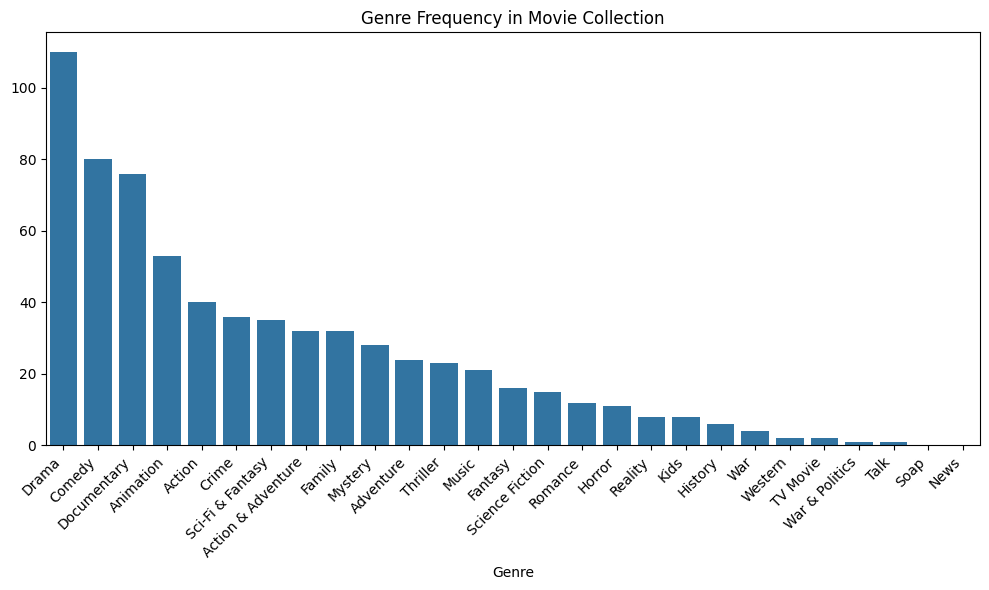

In [8]:
# Plot count of genres in the dataset
plt.figure(figsize=(10, 6))
genre_counts = merged_data[all_genres].sum().sort_values(ascending=False)
sns.barplot(x=genre_counts.index, y=genre_counts.values)
plt.title('Genre Frequency in Movie Collection')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Genre')
plt.tight_layout()
plt.show()

This bar chart displays the frequency distribution of genres across a movie collection, with Drama being the most prevalent genre, followed by Comedy and Documentary.

Summary Statistics for the Merged Dataset:


,popularity,vote_average,vote_count,Action & Adventure,Animation,Comedy,Crime,Documentary,Drama,Family,...,stock_return,market_return,abnormal_return,total_posts,total_comments,total_score,avg_upvote_ratio,high_engagement,high_comments,high_popularity
count,313.000000,313.000000,313.000000,313.000000,313.000000,313.000000,313.000000,313.000000,313.000000,313.000000,...,313.000000,313.000000,313.000000,313.000000,313.000000,313.000000,313.000000,313.000000,313.000000,313.000000
mean,3.091393,6.203696,328.779553,0.102236,0.169329,0.255591,0.115016,0.242812,0.351438,0.102236,...,0.255078,0.184290,0.070788,7.667732,733.488818,2109.434505,0.440841,0.498403,0.498403,0.498403
std,3.745819,2.597606,820.302934,0.303444,0.375643,0.436891,0.319552,0.429469,0.478184,0.303444,...,2.267728,0.981378,2.134890,16.388067,2147.277162,7092.633039,0.362840,0.500798,0.500798,0.500798
min,0.001000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-9.513179,-3.182365,-9.647522,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.459000,6.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.834363,-0.305496,-0.952399,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.612000,7.000000,87.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.009252,0.252133,-0.152213,2.000000,24.000000,22.000000,0.586667,0.000000,0.000000,0.000000
75%,3.889000,7.700000,236.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,...,1.181797,0.873125,0.923712,8.000000,407.000000,589.000000,0.758571,1.000000,1.000000,1.000000
max,39.971000,10.000000,6880.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,13.951882,3.679563,15.846439,176.000000,22197.000000,59363.000000,1.000000,1.000000,1.000000,1.000000


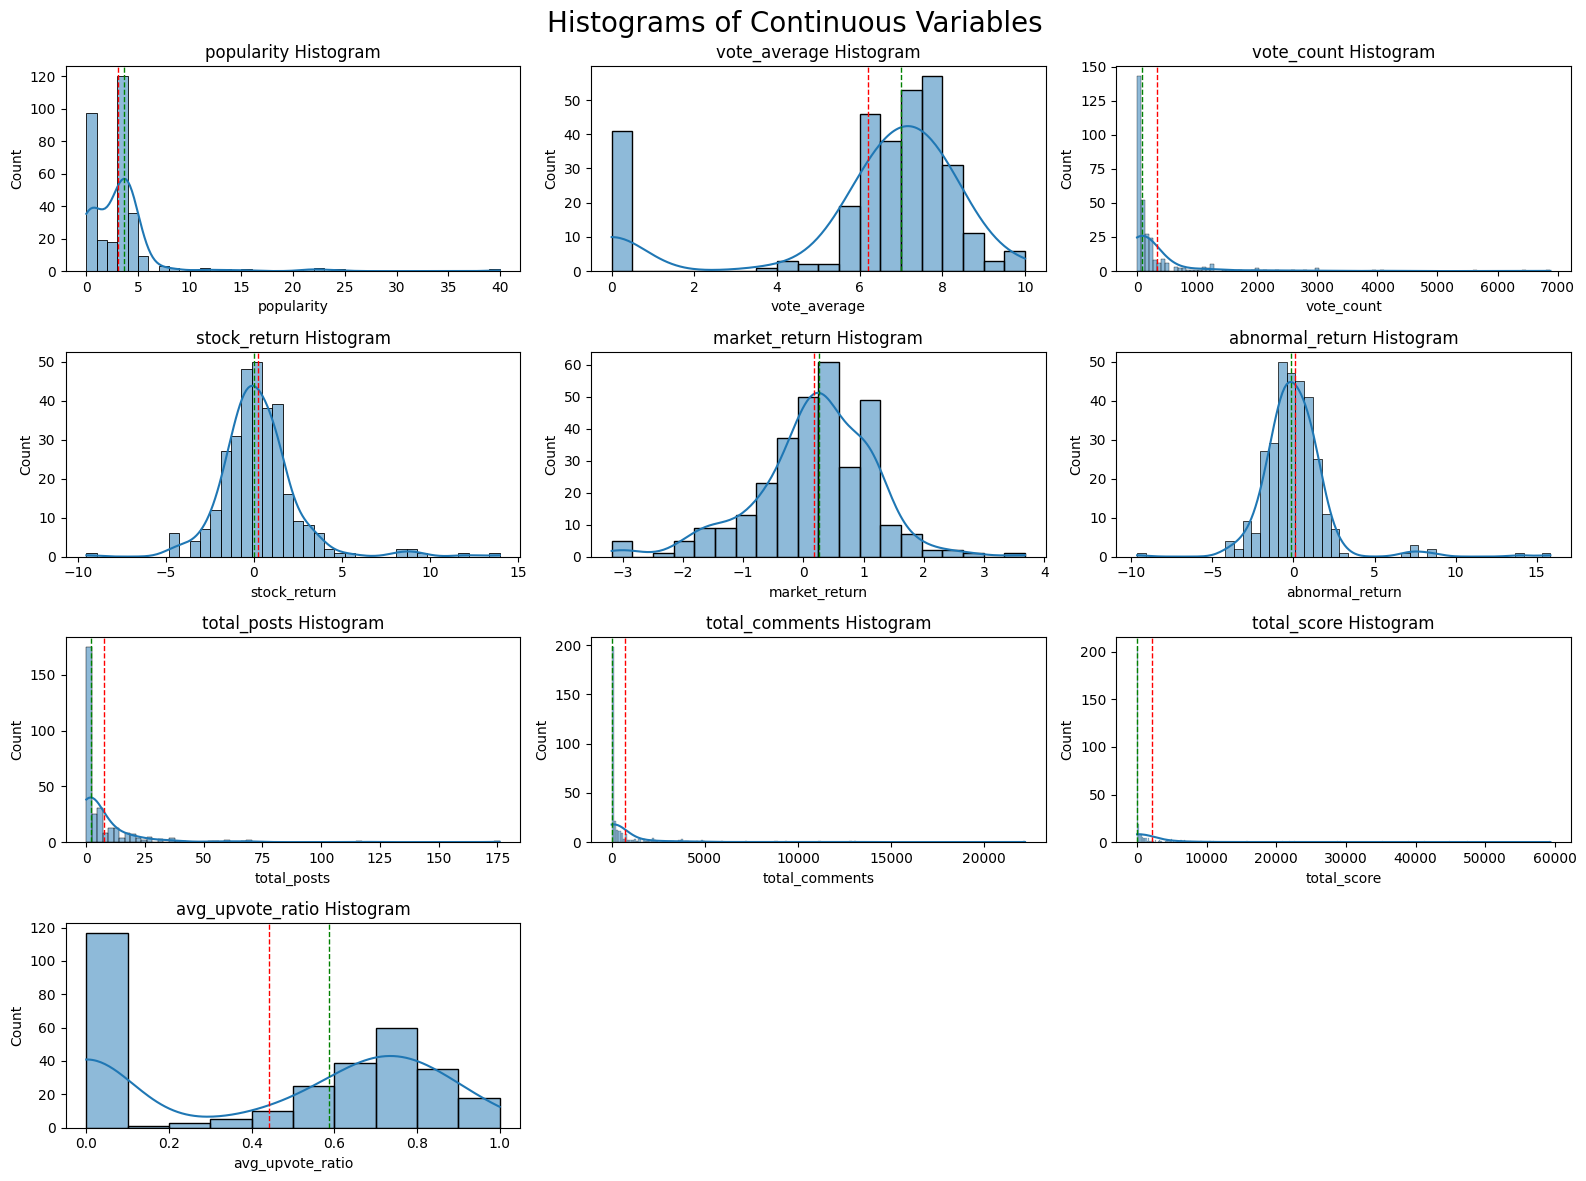

In [31]:
# Print the summary statistics for the merged dataset
merged_data_summary = merged_data.describe()
print("Summary Statistics for the Merged Dataset:")
display(merged_data_summary)

# Histograms for the numerical columns in the merged dataset
plt.figure(figsize=(16, 12))
plt.suptitle('Histograms of Continuous Variables', fontsize=20)

n_cols = 3
n_rows = 4

numerical_cols = ['popularity', 'vote_average', 'vote_count', 'stock_return', 
                  'market_return', 'abnormal_return', 'total_posts', 
                  'total_comments', 'total_score', 'avg_upvote_ratio']

for i, col in enumerate(numerical_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(merged_data[col], kde=True)
    plt.title(f'{col} Histogram')
    plt.axvline(merged_data[col].mean(), color='red', linestyle='dashed', linewidth=1, label=f'Mean: {merged_data[col].mean():.2f}')
    plt.axvline(merged_data[col].median(), color='green', linestyle='dashed', linewidth=1, label=f'Median: {merged_data[col].median():.2f}')

plt.tight_layout()
plt.show()

The histograms reveal several key patterns in the dataset examining digital media releases and market impact. Financial metrics display relatively normal distributions, with stock returns, market returns, and abnormal returns centered near zero. In contrast, content popularity metrics show pronounced right-skewed distributions, where most releases have relatively low popularity scores with only a few breakout hits achieving high ratings. Perhaps most striking is the distribution of social media engagement metrics, which are extremely right-skewed with the vast majority of content receiving minimal Reddit attention as evidenced by near-zero values for posts, comments, and scores. These distributions highlight the challenges in analyzing streaming content impact, where market returns follow expected statistical patterns but social engagement is characterized by extreme outliers and zero-inflation.

Text(0, 0.5, '3-Day Abnormal Return (%)')

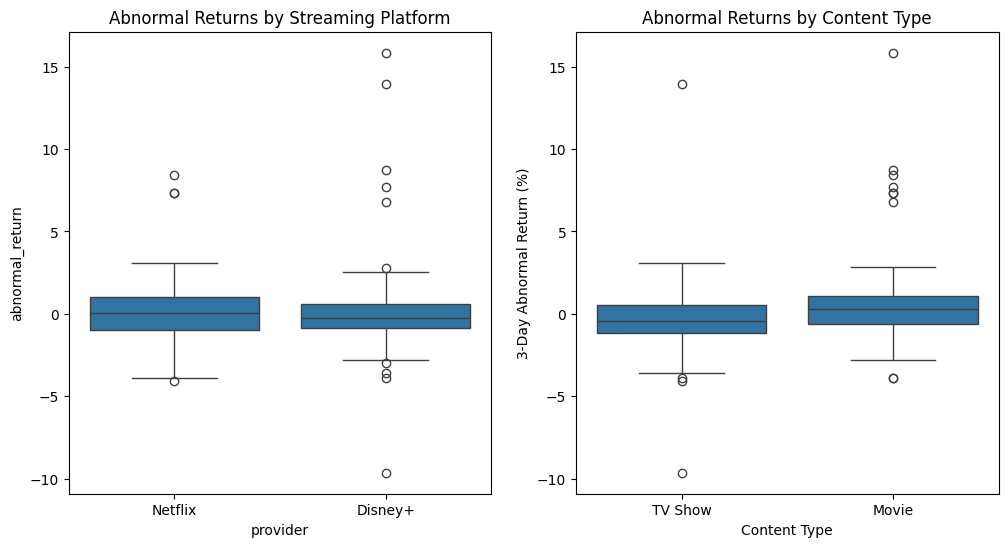

In [ ]:
n_rows = 1
n_cols = 2
# Boxplot of Abnormal Returns by Streaming Platform
plt.figure(figsize=(12, 6))
plt.subplot(n_rows, n_cols, 1)
sns.boxplot(x='provider', y='abnormal_return', data=merged_data)
plt.title('Abnormal Returns by Streaming Platform')

# Boxplot of Abnormal Returns by Content Type
plt.subplot(n_rows, n_cols, 2)
sns.boxplot(x='content-type', y='abnormal_return', data=merged_data)
plt.title('Abnormal Returns by Content Type')
plt.xlabel('Content Type')
plt.ylabel('3-Day Abnormal Return (%)')


The boxplots compare 3-day abnormal stock returns after content releases. Both Netflix and Disney+ show median returns near zero, though Disney+ has more extreme outliers. Similarly, TV shows and movies have comparable median returns, but movies display more positive outliers. Overall, most content releases have minimal stock price impact, though occasional releases trigger significant market reactions regardless of platform or content type.

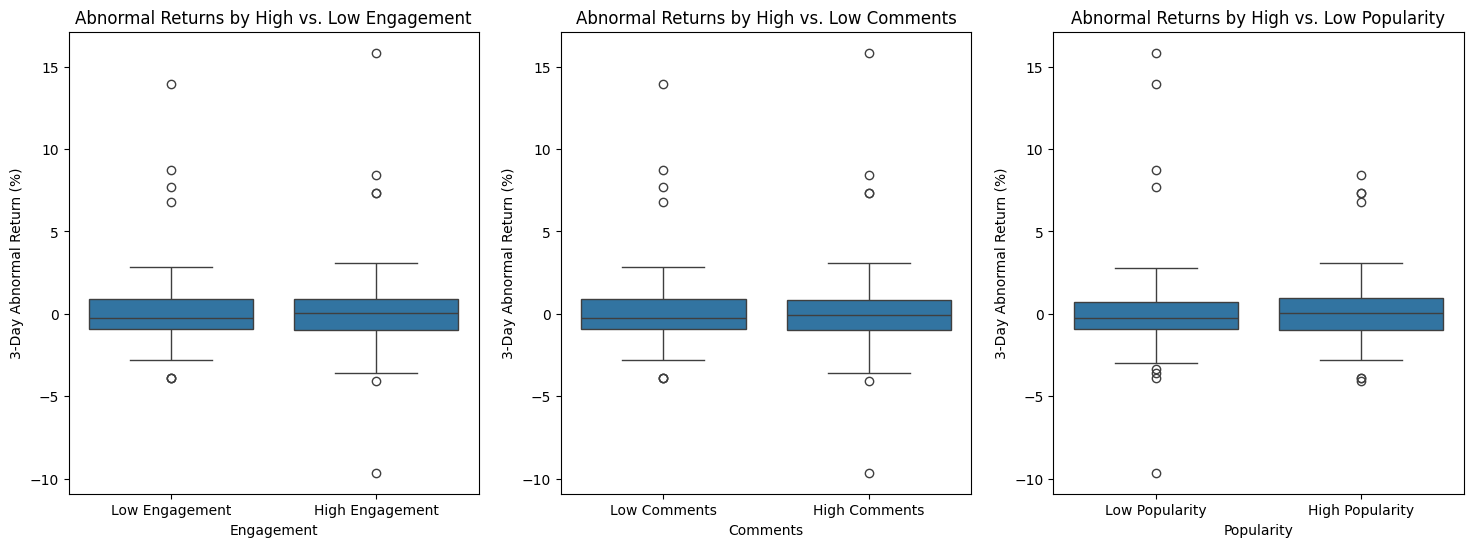

In [40]:
n_rows = 1
n_cols = 3
plt.figure(figsize=(18, 6))
# High vs. Low Engagement Boxplot
plt.subplot(n_rows, n_cols, 1)
sns.boxplot(x='high_engagement', y='abnormal_return', data=merged_data)
plt.title('Abnormal Returns by High vs. Low Engagement')
plt.xlabel('Engagement')
plt.ylabel('3-Day Abnormal Return (%)')
plt.xticks([0, 1], ['Low Engagement', 'High Engagement'])

# High vs. Low Comments Boxplot
plt.subplot(n_rows, n_cols, 2)
sns.boxplot(x='high_comments', y='abnormal_return', data=merged_data)
plt.title('Abnormal Returns by High vs. Low Comments')
plt.xlabel('Comments')
plt.ylabel('3-Day Abnormal Return (%)')
plt.xticks([0, 1], ['Low Comments', 'High Comments'])

# High vs. Low Popularity Boxplot
plt.subplot(n_rows, n_cols, 3)
sns.boxplot(x='high_popularity', y='abnormal_return', data=merged_data)
plt.title('Abnormal Returns by High vs. Low Popularity')
plt.xlabel('Popularity')
plt.ylabel('3-Day Abnormal Return (%)')
plt.xticks([0, 1], ['Low Popularity', 'High Popularity'])
plt.show()

The three boxplot panels compare 3-day abnormal stock returns between high and low levels of social media metrics. Across all panels, there appears to be minimal difference in the median abnormal returns between high and low categories, with both groups centered near 0%. All distributions show similar spreads and contain several outliers, with extreme positive outliers reaching approximately 15% and negative outliers reaching about -10%. This suggests that while individual content releases may occasionally produce notable stock price movements, the overall relationship between social media performance metrics and abnormal stock returns appears weak, with no clear pattern indicating that higher engagement, comments, or popularity leads to better or worse short-term stock performance.

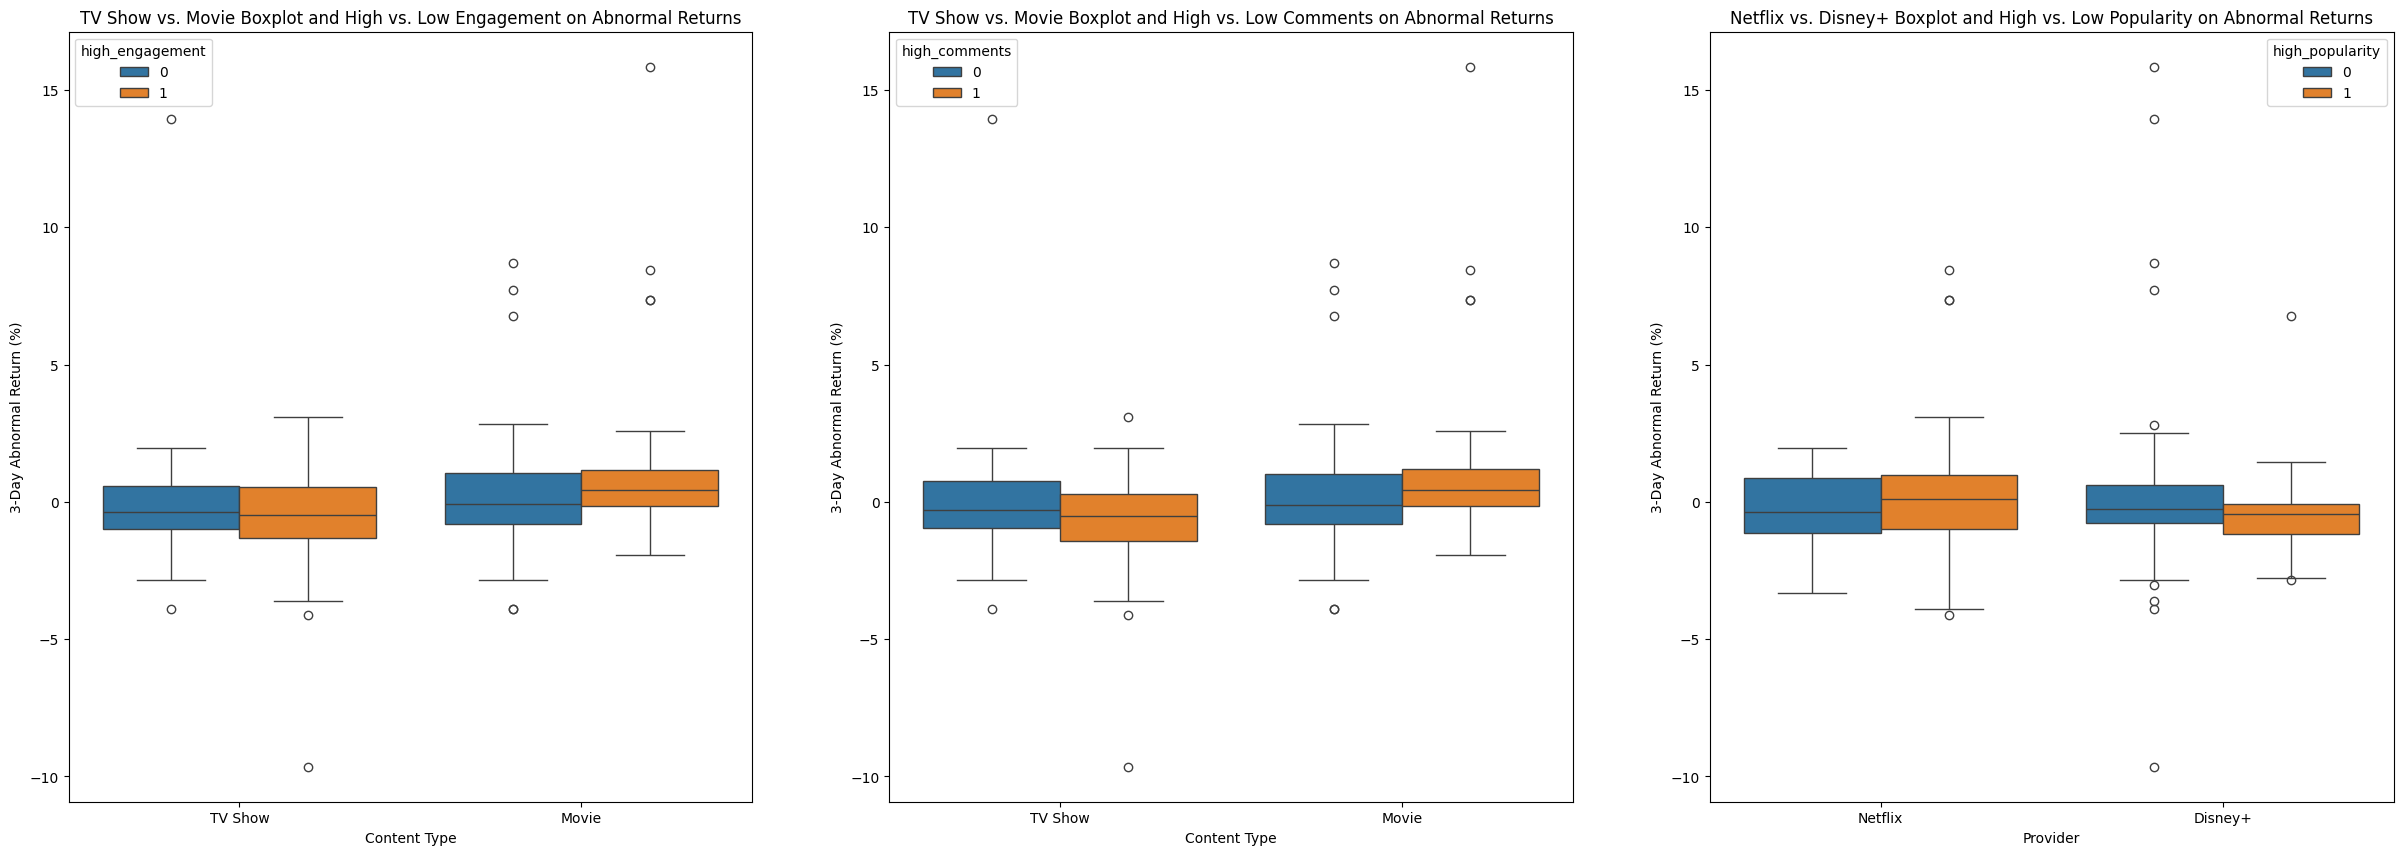

In [28]:
n_rows = 1
n_cols = 3
plt.figure(figsize=(30, 10))
# TV Show vs. Movie Boxplot and High vs. Low Engagement on Abnormal Returns
plt.subplot(n_rows, n_cols, 1)
sns.boxplot(x='content-type', y='abnormal_return', hue='high_engagement', data=merged_data)
plt.title('TV Show vs. Movie Boxplot and High vs. Low Engagement on Abnormal Returns')
plt.xlabel('Content Type')
plt.ylabel('3-Day Abnormal Return (%)')

# TV Show vs. Movie Boxplot and High vs. Low Comments on Abnormal Returns
plt.subplot(n_rows, n_cols, 2)
sns.boxplot(x='content-type', y='abnormal_return', hue='high_comments', data=merged_data)
plt.title('TV Show vs. Movie Boxplot and High vs. Low Comments on Abnormal Returns')
plt.xlabel('Content Type')
plt.ylabel('3-Day Abnormal Return (%)')

# Netflix vs. Disney+ Boxplot and High vs. Low Popularity on Abnormal Returns
plt.subplot(n_rows, n_cols, 3)
sns.boxplot(x='provider', y='abnormal_return', hue='high_popularity', data=merged_data)
plt.title('Netflix vs. Disney+ Boxplot and High vs. Low Popularity on Abnormal Returns')
plt.xlabel('Provider')
plt.ylabel('3-Day Abnormal Return (%)')
plt.show()


The boxplots compare abnormal stock returns across streaming content variables. Movies with high engagement and comment counts show slightly higher median returns than TV shows. This suggests investors may respond more positively to well-discussed films. Netflix exhibits a pattern where high-popularity content generates better returns, while Disney+ shows the opposite trend. The substantial variability and overlapping distributions indicate that while content type and engagement metrics may influence stock performance, these factors alone don't strongly predict market reactions to streaming releases.

In [ ]:
netflix_returns = merged_data[merged_data['provider'] == 'Netflix']['abnormal_return']
disney_returns = merged_data[merged_data['provider'] == 'Disney+']['abnormal_return']
t_stat, p_value = stats.ttest_ind(netflix_returns, disney_returns)
print("Netflix vs. Disney+ statistics:")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

high_eng_returns = merged_data[merged_data['high_engagement'] == 1]['abnormal_return']
low_eng_returns = merged_data[merged_data['high_engagement'] == 0]['abnormal_return']
t_stat, p_value = stats.ttest_ind(high_eng_returns, low_eng_returns)
print("High Engagement vs. Low Engagement statistics:")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")


Netflix vs. Disney+ statistics:
t-statistic: -0.0661
p-value: 0.9474
High Engagement vs. Low Engagement statistics:
t-statistic: -0.0157
p-value: 0.9875


Based on our statistical analysis, we found no significant relationship between streaming content releases and abnormal stock returns. When comparing Netflix and Disney+, the t-test yielded a t-statistic of -0.0661 with a p-value of 0.9474. This indicates virtually no difference in how content releases from these platforms impact their respective stock prices. Similarly, when examining the relationship between social media engagement and market reactions, we observed a t-statistic of -0.0157 and a p-value of 0.9875. Looking at this, it suggests that higher levels of online discussion do not translate to stronger stock market movements. These findings challenge the commonly held assumption that highly anticipated or widely discussed streaming content would materially affect company valuations in the short term. While streaming content is essential for subscriber retention and growth, our analysis suggests the market impact of individual releases is negligible. This indicates that such events may be too minor relative to these companies' overall business operations to drive significant stock price changes within a 3-day window.

# Summary
Our analysis found no significant relationship between streaming content releases and short-term stock market reactions, suggesting that individual content debuts may not substantially impact investor sentiment in the immediate 3-day window. For our final project, we plan to implement a more comprehensive temporal framework that examines multiple pre-release and post-release windows, allowing us to detect effects that might manifest over different time scales. This expanded approach will include teaser, marketing, and anticipation windows before release, along with immediate, short-term, medium-term, and long-term impact windows after release. \
We will develop a more sophisticated abnormal returns methodology, calculating cumulative abnormal returns for each window and computing their statistical significance using standard event study techniques. Additionally, we'll conduct detailed social media engagement analysis that tracks not just volume but engagement velocity, decay rates, and the relationship between pre-release buzz and post-release discussion. By creating advanced cross-domain metrics like engagement-to-return ratios and implementing more sophisticated statistical models with interaction terms, we aim to identify subtle patterns that may not be apparent in our preliminary analysis.